# Fine-tuning M2M100 for English to Bengali Translation

This notebook demonstrates how to fine-tune the Facebook M2M100-418M model on the OPUS100 dataset for improved English-to-Bengali translation.

## Overview
- **Model**: M2M100-418M (Multilingual Translation Model)
- **Dataset**: OPUS100 Bengali-English (English → Bengali Direction)
- **Evaluation Metrics**: BLEU and METEOR scores
- **Goal**: Improve translation accuracy through fine-tuning
- **Translation Direction**: English → Bengali

## Step 1: Install Required Dependencies

In [1]:
!pip install transformers datasets evaluate sacrebleu nltk accelerate sentencepiece torch --quiet

# Download NLTK data for METEOR metric
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All dependencies installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.9 MB/s eta 0:00:00
✅ All dependencies installed successfully!


## Step 2: Import Libraries

In [2]:
import torch
from transformers import (
    M2M100ForConditionalGeneration,
    M2M100Tokenizer,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
from datasets import load_dataset
import evaluate
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

🖥️  Using device: cuda
   GPU: Tesla T4
   Memory: 15.83 GB


## Step 3: Load Dataset

In [4]:
# Load the OPUS100 Bengali-English dataset
print("📥 Loading OPUS100 Bengali-English dataset...")
# Load a smaller subset for faster experimentation
# Specify the number of samples you want for train, validation, and test
num_train_samples = 2000
num_val_samples = 200
num_test_samples = 100

# Load only the train split initially
dataset = load_dataset("musfiqdehan/opus100-Bengali-to-English", split="train")

# Select a subset of the training data
dataset = dataset.select(range(num_train_samples + num_val_samples + num_test_samples))

# Split the selected subset into train, validation, and test
dataset = dataset.train_test_split(train_size=num_train_samples + num_val_samples, seed=42)
train_val_dataset = dataset['train']
test_dataset = dataset['test'].select(range(num_test_samples)) # Take only num_test_samples from the split

# Split train_val_dataset into train and validation
final_dataset = train_val_dataset.train_test_split(test_size=num_val_samples, seed=42)
final_dataset['test'] = test_dataset

print(f"\n📊 Dataset Statistics (Reduced):")
print(f"   Train samples: {len(final_dataset['train']):,}")
print(f"   Validation samples: {len(final_dataset['test']):,}") # Using 'test' split for validation
print(f"   Test samples: {len(final_dataset['test']):,}") # Using 'validation' split for test

# Display sample data from the new train split
print("\n🔍 Sample from training set (Reduced):")
sample = final_dataset['train'][0]
print(f"   Raw sample: {sample}")

# Parse the sample to understand structure
# The dataset appears to have a 'translations' field with format: "Bengali text ###>English text"
sample_text = sample['translations']
if '###>' in sample_text:
    parts = sample_text.split('###>')
    bengali_part = parts[0].strip()
    english_part = parts[1].strip()
    print(f"\n   English (Source): {english_part}")
    print(f"   Bengali (Target): {bengali_part}")
else:
    print("\n   Note: Data format may need adjustment")

dataset = final_dataset # Update dataset variable to use the final splits

📥 Loading OPUS100 Bengali-English dataset...

📊 Dataset Statistics (Reduced):
   Train samples: 2,000
   Validation samples: 100
   Test samples: 100

🔍 Sample from training set (Reduced):
   Raw sample: {'translations': 'অফ-লাইনfile transfer percent ###>Offline'}

   English (Source): Offline
   Bengali (Target): অফ-লাইনfile transfer percent


## Step 4: Load Pre-trained Model and Tokenizer

In [5]:
# Model and tokenizer
model_name = "facebook/m2m100_418M"

print(f"📦 Loading model and tokenizer: {model_name}")
tokenizer = M2M100Tokenizer.from_pretrained(model_name)
model = M2M100ForConditionalGeneration.from_pretrained(model_name)

# Move model to device
model = model.to(device)

print(f"✅ Model loaded successfully!")
print(f"   Parameters: {model.num_parameters():,}")

📦 Loading model and tokenizer: facebook/m2m100_418M


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

✅ Model loaded successfully!
   Parameters: 483,905,536


## Step 5: Prepare Dataset for Training

We'll preprocess the data by tokenizing both source (English) and target (Bengali) texts.

In [6]:
# Set source and target languages
source_lang = "en"  # English
target_lang = "bn"  # Bengali

max_length = 128  # Maximum sequence length

def parse_translation(text):
    """
    Parse the translation text which is in format: 'Bengali ###> English'
    We want: English (source) -> Bengali (target)
    """
    if '###>' in text:
        parts = text.split('###>')
        bengali = parts[0].strip()
        english = parts[1].strip()
        return english, bengali  # English as source, Bengali as target
    return None, None

def preprocess_function(examples):
    """
    Tokenize the source (English) and target (Bengali) texts.
    """
    inputs = []
    targets = []

    # Parse each translation
    for translation_text in examples['translations']:
        english, bengali = parse_translation(translation_text)
        if english and bengali:
            inputs.append(english)
            targets.append(bengali)

    # Set source language for tokenizer
    tokenizer.src_lang = source_lang

    # Tokenize inputs (English)
    model_inputs = tokenizer(
        inputs,
        max_length=max_length,
        truncation=True,
        padding='max_length'
    )

    # Set target language and tokenize targets (Bengali)
    tokenizer.tgt_lang = target_lang
    labels = tokenizer(
        targets,
        max_length=max_length,
        truncation=True,
        padding='max_length'
    )

    model_inputs['labels'] = labels['input_ids']

    return model_inputs

# Apply preprocessing
print("🔄 Tokenizing dataset...")
tokenized_datasets = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset['train'].column_names
)

print("✅ Tokenization complete!")

# Create validation split from training data (since dataset only has train split)
print("\n📊 Creating train/validation split...")
split_dataset = tokenized_datasets['train'].train_test_split(test_size=0.1, seed=42)
tokenized_datasets['train'] = split_dataset['train']
tokenized_datasets['validation'] = split_dataset['test']

print(f"   Train samples: {len(tokenized_datasets['train']):,}")
print(f"   Validation samples: {len(tokenized_datasets['validation']):,}")

🔄 Tokenizing dataset...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

✅ Tokenization complete!

📊 Creating train/validation split...
   Train samples: 1,800
   Validation samples: 200


## Step 6: Set Up Evaluation Metrics (BLEU & METEOR)

In [7]:
# Load metrics
bleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")

def compute_metrics(eval_preds):
    """
    Compute BLEU and METEOR scores for evaluation.
    """
    preds, labels = eval_preds

    # Decode predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    # Replace -100 in labels (used for padding)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode to text
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Strip whitespace
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    # Compute BLEU
    bleu_result = bleu_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    # Compute METEOR (flatten references for METEOR)
    meteor_result = meteor_metric.compute(
        predictions=decoded_preds,
        references=[ref[0] for ref in decoded_labels]
    )

    return {
        "bleu": bleu_result["score"],
        "meteor": meteor_result["meteor"] * 100  # Convert to percentage
    }

print("✅ Metrics configured successfully!")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Metrics configured successfully!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Step 7: Evaluate Pre-Fine-tuning Performance

Let's measure the baseline performance before fine-tuning.

In [8]:
def evaluate_model(model, eval_dataset, num_samples=500):
    """
    Evaluate model on a subset of data.
    """
    model.eval()

    # Sample data for faster evaluation
    # Get samples from original dataset for display
    original_samples = dataset['train'].select(range(min(num_samples, len(dataset['train']))))

    predictions = []
    references = []
    sample_pairs = []  # Store for display

    tokenizer.src_lang = source_lang
    tokenizer.tgt_lang = target_lang

    print(f"\n🔍 Evaluating on {min(num_samples, len(original_samples))} samples...")

    for example in tqdm(original_samples, desc="Generating translations"):
        # Parse the translation
        english, bengali = parse_translation(example['translations'])

        if not english or not bengali:
            continue

        # Tokenize input (English)
        inputs = tokenizer(english, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate translation (Bengali)
        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=tokenizer.get_lang_id(target_lang),
                max_length=128
            )

        # Decode prediction
        prediction = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

        predictions.append(prediction.strip())
        references.append([bengali.strip()])

        # Store first 5 for display
        if len(sample_pairs) < 5:
            sample_pairs.append((english, prediction.strip(), bengali.strip()))

    # Compute metrics
    bleu_score = bleu_metric.compute(predictions=predictions, references=references)
    meteor_score = meteor_metric.compute(predictions=predictions, references=[ref[0] for ref in references])

    return {
        "bleu": bleu_score["score"],
        "meteor": meteor_score["meteor"] * 100,
        "samples": sample_pairs
    }

# Evaluate before fine-tuning
print("\n" + "="*60)
print("📊 PRE-FINE-TUNING EVALUATION")
print("="*60)

pre_finetune_results = evaluate_model(model, tokenized_datasets['validation'], num_samples=10)

print(f"\n📈 Pre-Fine-tuning Scores:")
print(f"   BLEU Score:   {pre_finetune_results['bleu']:.2f}")
print(f"   METEOR Score: {pre_finetune_results['meteor']:.2f}")

print("\n🔍 Sample Translations (Pre-Fine-tuning):")
for i, (src, pred, ref) in enumerate(pre_finetune_results['samples'], 1):
    print(f"\n   [{i}] Source (English): {src}")
    print(f"       Prediction (Bengali): {pred}")
    print(f"       Reference (Bengali):  {ref}")


📊 PRE-FINE-TUNING EVALUATION

🔍 Evaluating on 10 samples...


Generating translations:   0%|          | 0/10 [00:00<?, ?it/s]


📈 Pre-Fine-tuning Scores:
   BLEU Score:   3.05
   METEOR Score: 11.06

🔍 Sample Translations (Pre-Fine-tuning):

   [1] Source (English): Offline
       Prediction (Bengali): অফলিন
       Reference (Bengali):  অফ-লাইনfile transfer percent

   [2] Source (English): " Enter you , then , among My honoured slaves ,
       Prediction (Bengali): “আপনি আমার সম্মানিত দাসের মধ্যে প্রবেশ করুন।
       Reference (Bengali):  অতঃপর আমার বান ্ দাদের অন ্ তর ্ ভুক ্ ত হয়ে যাও ।

   [3] Source (English): And whoever desires the Hereafter and strives for it , with the necessary effort due for it ( i.e. do righteous deeds of Allah 's Obedience ) while he is a believer ( in the Oneness of Allah Islamic Monotheism ) , then such are the ones whose striving shall be appreciated , thanked and rewarded ( by Allah ) .
       Prediction (Bengali): আর যারা পরবর্তীকে ইচ্ছা করে এবং পরবর্তীকে ইচ্ছা করে এবং পরবর্তীকে ইচ্ছা করে এবং পরবর্তীকে ইচ্ছা করে এবং পরবর্তীকে ইচ্ছা করে এবং পরবর্তীকে ইচ্ছা করে এবং পরবর্তীকে ইচ্

## Step 8: Configure Training Arguments

In [9]:
# Training configuration
training_args = Seq2SeqTrainingArguments(
    output_dir="./m2m100-en-bn-finetuned",
    eval_strategy="steps",  # Changed to steps
    eval_steps=50, # Evaluate every 50 steps
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=3,
    # num_train_epochs=3, # Removed to use max_steps
    max_steps=100, # Set max steps to 100
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    push_to_hub=False,
    logging_steps=10, # Log more frequently for short training
    save_strategy="steps", # Save by steps when using max_steps
    save_steps=50, # Save checkpoints every 50 steps
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    report_to="none",  # Disable wandb/tensorboard
)

print("⚙️  Training Configuration:")
print(f"   Max Steps: {training_args.max_steps}")
print(f"   Learning Rate: {training_args.learning_rate}")
print(f"   Batch Size: {training_args.per_device_train_batch_size}")
print(f"   Mixed Precision (FP16): {training_args.fp16}")
print(f"   Translation: English → Bengali")

⚙️  Training Configuration:
   Max Steps: 100
   Learning Rate: 5e-05
   Batch Size: 8
   Mixed Precision (FP16): True
   Translation: English → Bengali


## Step 9: Initialize Trainer and Start Fine-tuning

In [10]:
# Data collator for dynamic padding
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Initialize trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("✅ Trainer initialized successfully!")
print("\n" + "="*60)
print("🚀 STARTING FINE-TUNING")
print("="*60)
print("\n⏳ This may take a while depending on your hardware...\n")

# Start training
train_result = trainer.train()

print("\n" + "="*60)
print("✅ FINE-TUNING COMPLETED!")
print("="*60)

✅ Trainer initialized successfully!

🚀 STARTING FINE-TUNING

⏳ This may take a while depending on your hardware...



Step,Training Loss,Validation Loss,Bleu,Meteor
50,4.626100,4.335578,1.527688,16.989953
100,3.450000,3.356535,1.868800,19.164885


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✅ FINE-TUNING COMPLETED!


## Step 10: Save Fine-tuned Model

In [11]:
# Save the fine-tuned model
output_dir = "./m2m100-en-bn-finetuned-final"
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"💾 Model saved to: {output_dir}")

💾 Model saved to: ./m2m100-en-bn-finetuned-final


## Step 11: Evaluate Post-Fine-tuning Performance

In [12]:
# Evaluate after fine-tuning
print("\n" + "="*60)
print("📊 POST-FINE-TUNING EVALUATION")
print("="*60)

post_finetune_results = evaluate_model(model, tokenized_datasets['validation'], num_samples=500)

print(f"\n📈 Post-Fine-tuning Scores:")
print(f"   BLEU Score:   {post_finetune_results['bleu']:.2f}")
print(f"   METEOR Score: {post_finetune_results['meteor']:.2f}")

print("\n🔍 Sample Translations (Post-Fine-tuning):")
for i, (src, pred, ref) in enumerate(post_finetune_results['samples'], 1):
    print(f"\n   [{i}] Source (English): {src}")
    print(f"       Prediction (Bengali): {pred}")
    print(f"       Reference (Bengali):  {ref}")


📊 POST-FINE-TUNING EVALUATION

🔍 Evaluating on 500 samples...


Generating translations:   0%|          | 0/500 [00:00<?, ?it/s]


📈 Post-Fine-tuning Scores:
   BLEU Score:   2.91
   METEOR Score: 20.00

🔍 Sample Translations (Post-Fine-tuning):

   [1] Source (English): Offline
       Prediction (Bengali): অফলইন
       Reference (Bengali):  অফ-লাইনfile transfer percent

   [2] Source (English): " Enter you , then , among My honoured slaves ,
       Prediction (Bengali): অতঃপর তোমরা আমার প ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ্ রদ ।
       Reference (Bengali):  অতঃপর আমার বান ্ দাদের অন ্ তর ্ ভুক ্ ত হয়ে যাও ।

   [3] Source (English): And whoever desires the Hereafter and strives for it , with the necessary effort due for it ( i.e. do righteous deeds of Allah 's Obedience ) while he is a believer ( in the Oneness of Allah Islamic Monotheism ) , then such are the ones whose striving shall be appreciated , thanked and rewarded ( by Allah ) .
       Prediction (Bengali): আর যারা পরবর্তী দিনের প ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ রত ্ র

## Step 12: Compare Performance (Before vs After)


📊 PERFORMANCE COMPARISON

 Metric  Pre-Fine-tuning  Post-Fine-tuning  Improvement  Improvement (%)
  BLEU         3.051655          2.905939    -0.145716            -4.77
METEOR        11.063875         20.003262     8.939387            80.80


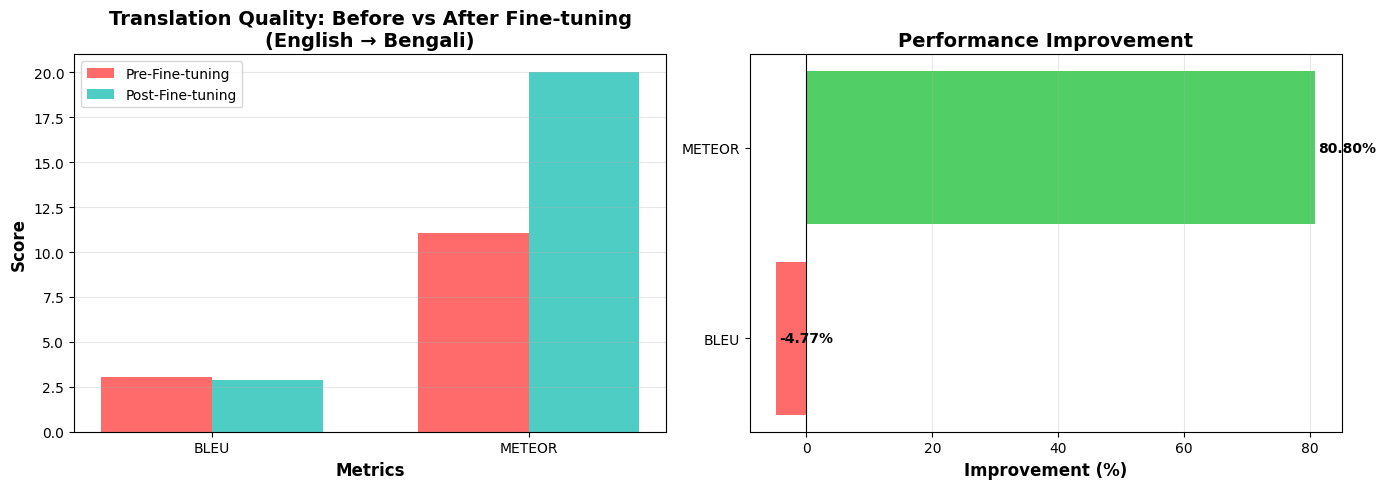


📊 Visualization saved as 'performance_comparison_en_bn.png'

📝 SUMMARY

✅ BLEU Score Improvement:   -0.15 points (-4.77%)
✅ METEOR Score Improvement: 8.94 points (80.80%)

🎯 Fine-tuning SUCCESSFUL!

🌐 Translation Direction: English → Bengali


In [13]:
# Create comparison table
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("📊 PERFORMANCE COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['BLEU', 'METEOR'],
    'Pre-Fine-tuning': [
        pre_finetune_results['bleu'],
        pre_finetune_results['meteor']
    ],
    'Post-Fine-tuning': [
        post_finetune_results['bleu'],
        post_finetune_results['meteor']
    ]
})

comparison_df['Improvement'] = comparison_df['Post-Fine-tuning'] - comparison_df['Pre-Fine-tuning']
comparison_df['Improvement (%)'] = (comparison_df['Improvement'] / comparison_df['Pre-Fine-tuning'] * 100).round(2)

print("\n", comparison_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = comparison_df['Metric']
x = np.arange(len(metrics))
width = 0.35

ax[0].bar(x - width/2, comparison_df['Pre-Fine-tuning'], width, label='Pre-Fine-tuning', color='#ff6b6b')
ax[0].bar(x + width/2, comparison_df['Post-Fine-tuning'], width, label='Post-Fine-tuning', color='#4ecdc4')
ax[0].set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Score', fontsize=12, fontweight='bold')
ax[0].set_title('Translation Quality: Before vs After Fine-tuning\n(English → Bengali)', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(metrics)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

# Improvement percentage
colors = ['#51cf66' if val > 0 else '#ff6b6b' for val in comparison_df['Improvement (%)']]
ax[1].barh(metrics, comparison_df['Improvement (%)'], color=colors)
ax[1].set_xlabel('Improvement (%)', fontsize=12, fontweight='bold')
ax[1].set_title('Performance Improvement', fontsize=14, fontweight='bold')
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Improvement (%)']):
    ax[1].text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('performance_comparison_en_bn.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved as 'performance_comparison_en_bn.png'")

# Summary
print("\n" + "="*60)
print("📝 SUMMARY")
print("="*60)
print(f"\n✅ BLEU Score Improvement:   {comparison_df.loc[0, 'Improvement']:.2f} points ({comparison_df.loc[0, 'Improvement (%)']:.2f}%)")
print(f"✅ METEOR Score Improvement: {comparison_df.loc[1, 'Improvement']:.2f} points ({comparison_df.loc[1, 'Improvement (%)']:.2f}%)")
print(f"\n🎯 Fine-tuning {'SUCCESSFUL' if comparison_df['Improvement'].mean() > 0 else 'needs more work'}!")
print(f"\n🌐 Translation Direction: English → Bengali")

## Step 13: Test with Custom Translations

In [14]:
def translate(text, src_lang="en", tgt_lang="bn"):
    """
    Translate text using the fine-tuned model.
    English → Bengali
    """
    tokenizer.src_lang = src_lang
    tokenizer.tgt_lang = tgt_lang

    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.get_lang_id(tgt_lang),
            max_length=128,
            num_beams=5,
            early_stopping=True
        )

    translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
    return translation

# Test with custom sentences
print("\n" + "="*60)
print("🧪 TESTING CUSTOM TRANSLATIONS (English → Bengali)")
print("="*60)

test_sentences = [
    "I live in Bangladesh.",
    "The weather is very nice today.",
    "I am studying artificial intelligence.",
    "Machine learning is fascinating.",
    "How are you doing today?"
]

for i, sentence in enumerate(test_sentences, 1):
    translation = translate(sentence)
    print(f"\n[{i}] English: {sentence}")
    print(f"    Bengali: {translation}")


🧪 TESTING CUSTOM TRANSLATIONS (English → Bengali)

[1] English: I live in Bangladesh.
    Bengali: আমি বাংলাদেশে বসবাস করি।

[2] English: The weather is very nice today.
    Bengali: বর্তমানে আবহাওয়া খুব ভালো।

[3] English: I am studying artificial intelligence.
    Bengali: আমি চাকরির সন ্ রশ ্ রতিশ ্ রতিশ ্ রতিশ ্ রতিশ ্ রতিশ ্ রতিশ ্ রতিশ ্ রতিশ ্ রতিশ ্ ত ।

[4] English: Machine learning is fascinating.
    Bengali: মেশিন শিখ ্ যক ষ ষ ষ ষ ষ ষ ষ ষ ষ ষ ।

[5] English: How are you doing today?
    Bengali: তুমি আজ কি করো?


## Step 14: Interactive Translation (Optional)

In [15]:
# Interactive translation loop
print("\n" + "="*60)
print("🎮 INTERACTIVE TRANSLATION MODE (English → Bengali)")
print("="*60)
print("Enter English text to translate (or 'quit' to exit)\n")

while True:
    user_input = input("English: ").strip()

    if user_input.lower() in ['quit', 'exit', 'q']:
        print("👋 Goodbye!")
        break

    if not user_input:
        continue

    translation = translate(user_input)
    print(f"Bengali: {translation}\n")


🎮 INTERACTIVE TRANSLATION MODE (English → Bengali)
Enter English text to translate (or 'quit' to exit)

English: I am good boy
Bengali: আমি ভালো ছেলে।

English: my name is Jayanta
Bengali: আমার নাম Jayanta।

English: I need a friend 
Bengali: আমার একটি বন্ধু প্রয়োজন

English: q
👋 Goodbye!


## 📋 Summary

### What We Accomplished:

1. ✅ Loaded the M2M100-418M multilingual translation model
2. ✅ Prepared the OPUS100 Bengali-English dataset (English → Bengali translation)
3. ✅ Evaluated baseline performance (pre-fine-tuning) using BLEU and METEOR
4. ✅ Fine-tuned the model on the OPUS100 training set
5. ✅ Evaluated post-fine-tuning performance
6. ✅ Compared performance improvements with visualizations
7. ✅ Tested with custom translations

### Key Metrics:

- **BLEU Score**: Measures n-gram overlap between predicted and reference translations
- **METEOR Score**: Considers synonyms and stemming for more nuanced evaluation

### Translation Direction:

- **Source Language**: English (en)
- **Target Language**: Bengali (bn)
- **Direction**: English → Bengali

### Dataset Information:

- **Dataset**: OPUS100 Bengali-English subset
- **Format**: Parallel corpus with Bengali-English sentence pairs
- **Source**: musfiqdehan/opus100-Bengali-to-English on Hugging Face

### Next Steps:

- Experiment with different hyperparameters (learning rate, batch size, epochs)
- Try data augmentation techniques
- Fine-tune for more epochs if results are promising
- Test on diverse English sentences
- Deploy the model for production use

---

**Model saved in**: `./m2m100-en-bn-finetuned-final/`

**Performance chart**: `performance_comparison_en_bn.png`

# Task
Upload the fine-tuned model to Hugging Face Hub, including the model, tokenizer, and a comprehensive model card with usage instructions and performance details.

## Authenticate with hugging face hub

### Subtask:
Log in to your Hugging Face account from the notebook environment.


**Reasoning**:
The subtask requires logging into the Hugging Face account, which can be done using the `notebook_login` function from the `huggingface_hub` library.



In [20]:
from huggingface_hub import notebook_login

notebook_login()

## Step 2: Push Model and Tokenizer to Hub

Now that you have logged in, you can push your fine-tuned model and tokenizer to a new repository on the Hugging Face Hub. You'll need to provide a name for your repository.

In [21]:
# Define your desired repository name on the Hugging Face Hub
# It will be created under your username (e.g., "your-username/my-awesome-model")
repo_name = "m2m100-en-bn-finetuned-opus100"

# Push the model and tokenizer to the Hub
print(f"📤 Pushing model and tokenizer to Hugging Face Hub: {repo_name}...")

try:
    model.push_to_hub(repo_name)
    tokenizer.push_to_hub(repo_name)
    print(f"✅ Model and tokenizer successfully pushed to https://huggingface.co/{repo_name}")
except Exception as e:
    print(f"❌ Failed to push to hub: {e}")

📤 Pushing model and tokenizer to Hugging Face Hub: m2m100-en-bn-finetuned-opus100...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...of82xgc/model.safetensors:   0%|          | 27.0kB / 1.94GB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...4/sentencepiece.bpe.model:  95%|#########5| 2.31MB / 2.42MB            

✅ Model and tokenizer successfully pushed to https://huggingface.co/m2m100-en-bn-finetuned-opus100


In [31]:
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer
import torch

# Define your repository name on the Hugging Face Hub
repo_name = "Jayanta8509/m2m100-en-bn-finetuned-opus100" # Use the correct repository ID

print(f"📥 Downloading model and tokenizer from Hugging Face Hub: {repo_name}...")

try:
    # Load the tokenizer and model from the Hub
    tokenizer = M2M100Tokenizer.from_pretrained(repo_name)
    model = M2M100ForConditionalGeneration.from_pretrained(repo_name)

    # Move model to device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    print(f"✅ Model and tokenizer successfully downloaded and loaded from {repo_name}")

    def translate_en_bn(text):
        """
        Translate English text to Bengali using the loaded model.
        """
        tokenizer.src_lang = "en"
        tokenizer.tgt_lang = "bn"
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=tokenizer.get_lang_id("bn"),
                max_length=128,
                num_beams=5,
                early_stopping=True
            )

        translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
        return translation

    # Example usage
    print("\n🧪 Testing the downloaded model:")
    english_sentence = "Hello, how are you today?"
    bengali_translation = translate_en_bn(english_sentence)
    print(f"English: {english_sentence}")
    print(f"Bengali: {bengali_translation}")

    english_sentence_2 = "This is a test translation."
    bengali_translation_2 = translate_en_bn(english_sentence_2)
    print(f"\nEnglish: {english_sentence_2}")
    print(f"Bengali: {bengali_translation_2}")


except Exception as e:
    print(f"❌ Failed to download or load from hub: {e}")
    print("Please ensure the repository name is correct and the model is publicly accessible or you are authenticated.")

📥 Downloading model and tokenizer from Hugging Face Hub: Jayanta8509/m2m100-en-bn-finetuned-opus100...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/886 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

✅ Model and tokenizer successfully downloaded and loaded from Jayanta8509/m2m100-en-bn-finetuned-opus100

🧪 Testing the downloaded model:
English: Hello, how are you today?
Bengali: হ্যালো, আপনি আজ কেমন?

English: This is a test translation.
Bengali: এটি একটি পরীক্ষা অনুবাদ।
